In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_dir_func_calls(data_dir, reproduced_bugs=None):
    result_list = []
    for fname in sorted(os.listdir(data_dir)):
        if os.path.isdir(os.path.join(data_dir, fname)):
            continue
        with open(os.path.join(data_dir, fname)) as f:
            run_info = json.load(f)
        bug_name = fname.removeprefix("XFL-").removesuffix(".json")
        if reproduced_bugs is not None and bug_name not in reproduced_bugs:
            continue
        inf_length = (
            len([e for e in run_info["messages"] if e["role"] == "assistant"]) - 1
        )
        func_call_sequence = "-".join(
            [e["name"] for e in run_info["messages"] if e["role"] == "function"]
        )

        result_list.append(
            {
                "inf_length": inf_length,
                "bug_name": bug_name,
                "project": bug_name.split("_")[0],
                "func_calls": func_call_sequence,
            }
        )
    return pd.DataFrame(result_list)

def calc_exp_level_avg_func_calls(exp_list, repetition):
    summary_list = []
    
    for exp in exp_list:
        df = get_dir_func_calls(f"../results/{exp['name']}/R_{repetition}/{exp['gpt_version']}")
        num_bugs = df["bug_name"].nunique()
        if num_bugs == 0: continue

        df["func_calls_list"] = df["func_calls"].apply(lambda x: x.split("-") if x else [])
        exploded = df.explode("func_calls_list")
                
        func_counts = exploded.groupby("func_calls_list").size().reset_index(name="total_count")
        func_counts["avg_call_count"] = func_counts["total_count"] / num_bugs
        func_counts["exp_label"] = exp['label']
        
        summary_list.append(func_counts)
    
    return pd.concat(summary_list, ignore_index=True)

def visualize_avg_function_call_per_bug(exp_list, repetition, fig_title):
    plot_data = calc_exp_level_avg_func_calls(exp_list, repetition)
    
    plt.figure(figsize=(14, 8))
    sns.set_style("whitegrid")
    
    ax = sns.barplot(
        data=plot_data,
        x="exp_label",
        y="avg_call_count",
        hue="func_calls_list",
        palette="tab10"
    )

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', 
                        fontsize=9, xytext=(0, 5),
                        textcoords='offset points')

    plt.title(f"Average Function Calls per Bug by Experiment - {fig_title}", fontsize=16)
    plt.xlabel("Experiments", fontsize=12)
    plt.ylabel("Average Calls per Bug (Overall)", fontsize=12)
    plt.legend(title="Functions", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


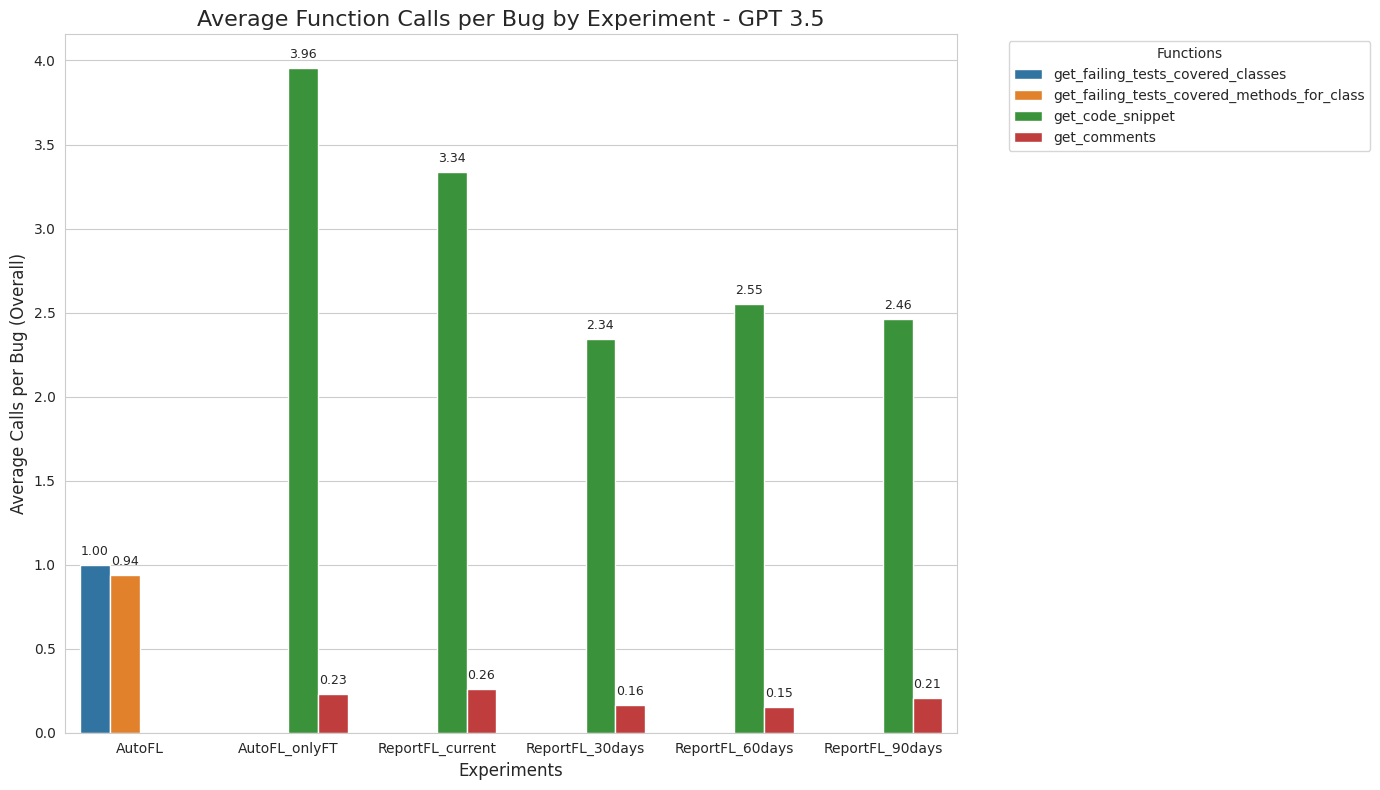

In [2]:
EXP_LIST = [
    {
        "name": "autofl",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "AutoFL",
    },
    {
        "name": "autofl_onlyft",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "AutoFL_onlyFT",
    },
    {
        "name": "current",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_current",
    },
    {
        "name": "reportfl",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_30days",
    },    
    {
        "name": "reportfl_60days",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_60days",
    },
    {
        "name": "reportfl_90days",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_90days",
    }
]

visualize_avg_function_call_per_bug(EXP_LIST, repetition=1, fig_title="GPT 3.5")

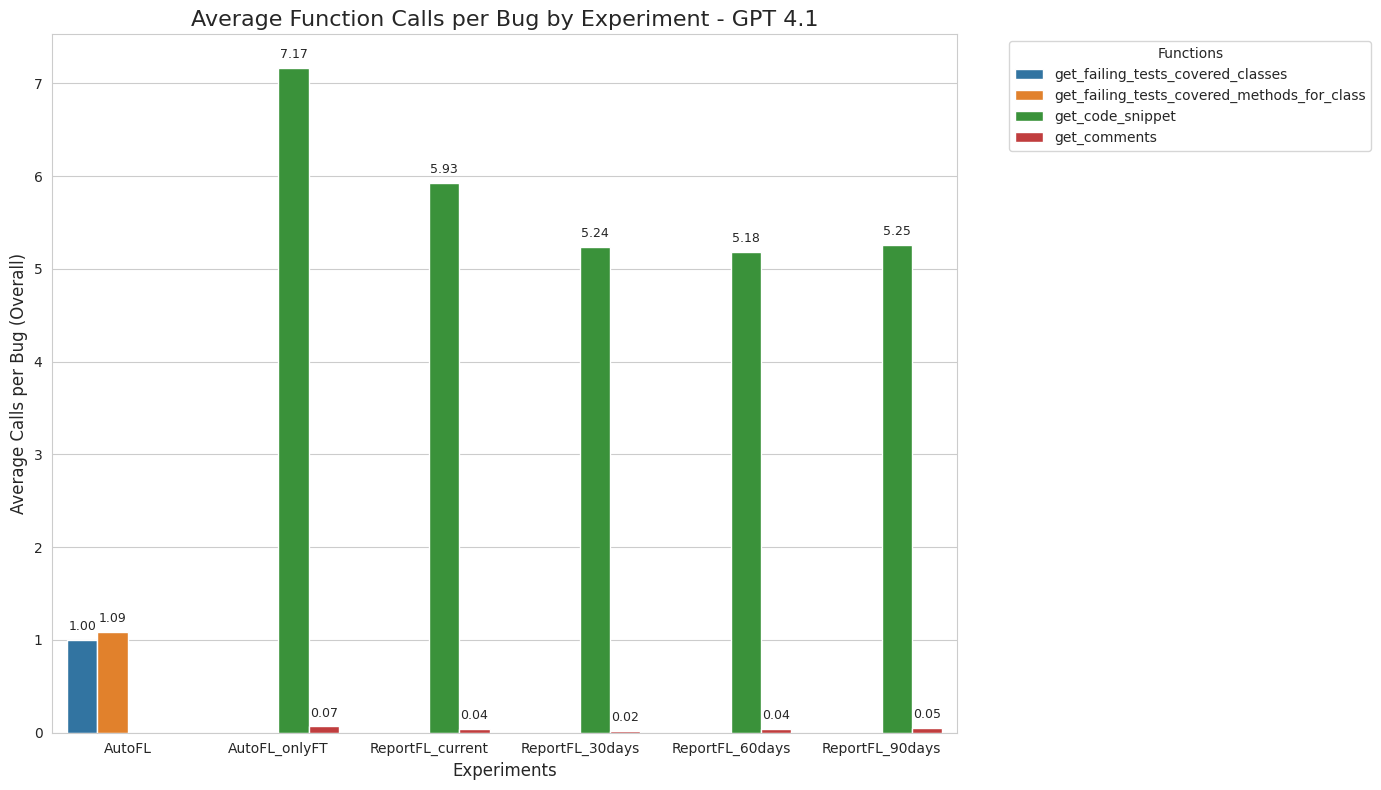

In [3]:
EXP_LIST = [
    {
        "name": "autofl",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "AutoFL",
    },
    {
        "name": "autofl_onlyft",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "AutoFL_onlyFT",
    },
    {
        "name": "current",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_current",
    },
    {
        "name": "reportfl",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_30days",
    },    
    {
        "name": "reportfl_60days",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_60days",
    },
    {
        "name": "reportfl_90days",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_90days",
    }
]

visualize_avg_function_call_per_bug(EXP_LIST, repetition=1, fig_title="GPT 4.1")